Arquivo carregado: 298062 registros
Cenários disponíveis: ['S_I' 'S_II' 'S_III' 'S_IV' 'S_V' 'S_VI' 'S_VII' 'S_VIII' 'S_IX' 'S_X'
 'S_XI' 'S_XII' 'S_XIII' 'S_XIV' 'S_XV' 'S_XVI' 'S_XVII' 'S_XVIII']
Total de registros no cenário CVIII: 0
Setores únicos: 0

ANÁLISE DE MUDANÇAS DE PERFIL COMPORTAMENTAL - CENÁRIO CVIII
Randomized population + Income dynamics

--- ESTATÍSTICAS GERAIS ---
Total de setores analisados: 0
Total de consumidores: 0
Total de mudanças de perfil: 0
Percentual global de mudanças: nan%

TOP 10 SETORES - MAIOR NÚMERO ABSOLUTO DE MUDANÇAS
RANK   SETOR        N_MUDANCAS      N_CONSUMIDORES     PCT_MUDANCAS    Perfil Inicial       Perfil Final        
--------------------------------------------------------------------------------------------------------------

TOP 10 SETORES - MAIOR PERCENTUAL DE MUDANÇAS
RANK   SETOR        PCT_MUDANCAS    N_MUDANCAS      N_CONSUMIDORES     Perfil Inicial       Perfil Final        
-------------------------------------------------------

C:\Users\E124796\AppData\Local\Temp\2\ipykernel_14548\3754286762.py:86: RuntimeWarning: invalid value encountered in scalar divide
  print(f"Percentual global de mudanças: {(total_mudancas/total_consumidores)*100:.2f}%")


Gráfico salvo em: ..\resultados\analises_mudanca\grafico_mudancas_perfil_CVIII.pdf


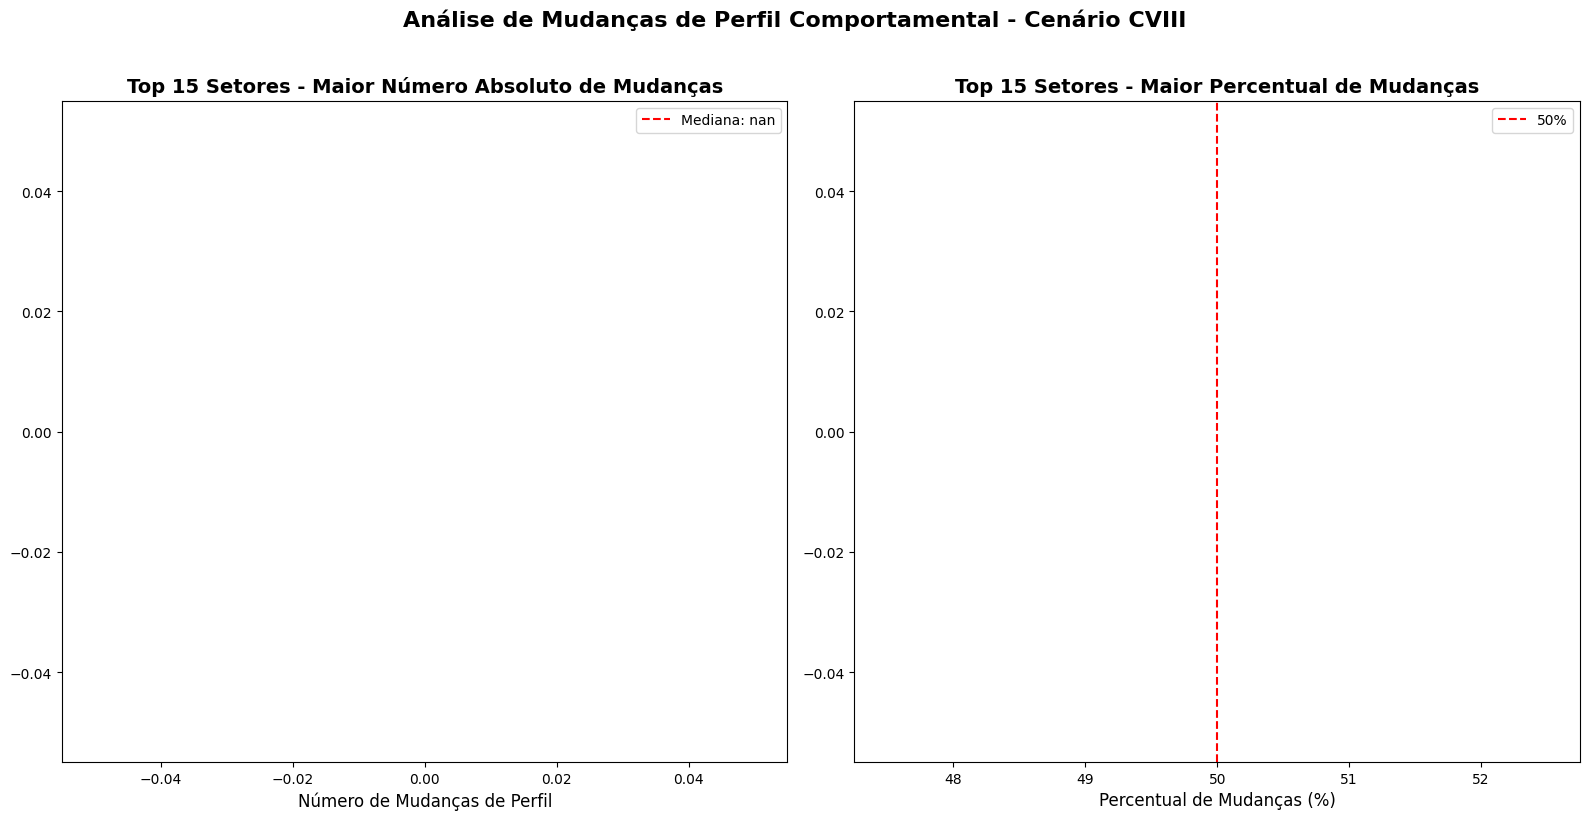

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ==========================================
# 1. Configuration
# ==========================================
BASE_PATH = '..'
INPUT_DIR_RES = os.path.join(BASE_PATH, 'resultados')
OUTPUT_DIR = os.path.join(BASE_PATH, 'resultados','analises_mudanca')
INPUT_FILE = 'comparativo_perfil_cenarios_qgis_2026_2035.csv'

def analyze_profile_changes_scenario(df, output_dir, scenario_escolhido):
    """
    Analyze and rank sectors with the most behavioral profile changes
    for a given scenario.
    """
    
    # Filter only the selected scenario
    df_scenario = df[df['NM_CENARIO'] == scenario_escolhido].copy()
    
    print(f"Total de registros no cenário {scenario_escolhido}: {len(df_scenario)}")
    print(f"Setores únicos: {df_scenario['CD_SETOR'].nunique()}")
    
    # ==========================================
    # 2. Identify profile changes
    # ==========================================
    
    # Mark whether behavior changed
    df_scenario['MUDOU_COMPORTAMENTO'] = df_scenario['TP_COMPORTAMENTO'] != df_scenario['TP_NOVO_COMPORTAMENTO']
    
    # ==========================================
    # 3. Sector-level analysis
    # ==========================================
    
    # Group by sector and calculate metrics
    sector_analysis = df_scenario.groupby('CD_SETOR').agg({
        'SK_MATRICULA': 'count',  # Total consumers in sector
        'MUDOU_COMPORTAMENTO': 'sum',  # Number of consumers who changed behavior
        'TP_COMPORTAMENTO': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'N/A',  # Most common initial profile
        'TP_NOVO_COMPORTAMENTO': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'N/A'  # Most common final profile
    }).reset_index()
    
    # Rename columns
    sector_analysis.columns = ['CD_SETOR', 'N_CONSUMIDORES', 'N_MUDANCAS', 
                               'PERFIL_PREDOMINANTE_INICIAL', 'PERFIL_PREDOMINANTE_FINAL']
    
    # Calculate percentage of changes
    sector_analysis['PCT_MUDANCAS'] = (sector_analysis['N_MUDANCAS'] / sector_analysis['N_CONSUMIDORES']) * 100
    
    # Identify transition patterns
    transicoes = df_scenario[df_scenario['MUDOU_COMPORTAMENTO']].groupby(
        ['CD_SETOR', 'TP_COMPORTAMENTO', 'TP_NOVO_COMPORTAMENTO']
    ).size().reset_index(name='COUNT')
    
    # ==========================================
    # 4. Sector ranking
    # ==========================================
    
    # Ranking by absolute number of changes
    ranking_absoluto = sector_analysis.sort_values('N_MUDANCAS', ascending=False).reset_index(drop=True)
    ranking_absoluto['RANK_ABSOLUTO'] = ranking_absoluto.index + 1
    
    # Ranking by percentage of changes
    ranking_percentual = sector_analysis.sort_values('PCT_MUDANCAS', ascending=False).reset_index(drop=True)
    ranking_percentual['RANK_PERCENTUAL'] = ranking_percentual.index + 1
    
    # ==========================================
    # 5. Display results
    # ==========================================
    
    print("\n" + "="*100)
    print(f"ANÁLISE DE MUDANÇAS DE PERFIL COMPORTAMENTAL - CENÁRIO {scenario_escolhido}")
    print("Randomized population + Income dynamics")
    print("="*100)
    
    # General statistics
    total_mudancas = sector_analysis['N_MUDANCAS'].sum()
    total_consumidores = sector_analysis['N_CONSUMIDORES'].sum()
    print(f"\n--- ESTATÍSTICAS GERAIS ---")
    print(f"Total de setores analisados: {len(sector_analysis)}")
    print(f"Total de consumidores: {total_consumidores}")
    print(f"Total de mudanças de perfil: {total_mudancas}")
    print(f"Percentual global de mudanças: {(total_mudancas/total_consumidores)*100:.2f}%")
    
    # TOP 10 sectors with MOST CHANGES (absolute)
    print("\n" + "="*100)
    print("TOP 10 SETORES - MAIOR NÚMERO ABSOLUTO DE MUDANÇAS")
    print("="*100)
    print(f"{'RANK':<6} {'SETOR':<12} {'N_MUDANCAS':<15} {'N_CONSUMIDORES':<18} {'PCT_MUDANCAS':<15} {'Perfil Inicial':<20} {'Perfil Final':<20}")
    print("-" * 110)
    for _, row in ranking_absoluto.head(10).iterrows():
        print(f"{row['RANK_ABSOLUTO']:<6} {row['CD_SETOR']:<12} {row['N_MUDANCAS']:<15} "
              f"{row['N_CONSUMIDORES']:<18} {row['PCT_MUDANCAS']:>6.1f}%      "
              f"{row['PERFIL_PREDOMINANTE_INICIAL']:<20} {row['PERFIL_PREDOMINANTE_FINAL']:<20}")
    
    # TOP 10 sectors with HIGHEST PERCENTAGE of changes
    print("\n" + "="*100)
    print("TOP 10 SETORES - MAIOR PERCENTUAL DE MUDANÇAS")
    print("="*100)
    print(f"{'RANK':<6} {'SETOR':<12} {'PCT_MUDANCAS':<15} {'N_MUDANCAS':<15} {'N_CONSUMIDORES':<18} {'Perfil Inicial':<20} {'Perfil Final':<20}")
    print("-" * 110)
    for _, row in ranking_percentual.head(10).iterrows():
        print(f"{row['RANK_PERCENTUAL']:<6} {row['CD_SETOR']:<12} {row['PCT_MUDANCAS']:>6.1f}%      "
              f"{row['N_MUDANCAS']:<15} {row['N_CONSUMIDORES']:<18} "
              f"{row['PERFIL_PREDOMINANTE_INICIAL']:<20} {row['PERFIL_PREDOMINANTE_FINAL']:<20}")
    
    # ==========================================
    # 6. Profile transition analysis by sector
    # ==========================================
    
    print("\n" + "="*100)
    print("PRINCIPAIS TRANSIÇÕES DE PERFIL POR SETOR")
    print("="*100)
    
    # For each top 5 sector, show main transitions
    top_setores = ranking_absoluto.head(5)['CD_SETOR'].tolist()
    
    for setor in top_setores:
        transicoes_setor = transicoes[transicoes['CD_SETOR'] == setor].sort_values('COUNT', ascending=False)
        print(f"\n--- Setor {setor} ---")
        print(f"Total de consumidores: {sector_analysis[sector_analysis['CD_SETOR'] == setor]['N_CONSUMIDORES'].values[0]}")
        print(f"Total de mudanças: {sector_analysis[sector_analysis['CD_SETOR'] == setor]['N_MUDANCAS'].values[0]}")
        print("Principais transições:")
        for _, trans in transicoes_setor.head(5).iterrows():
            print(f"  {trans['TP_COMPORTAMENTO']} → {trans['TP_NOVO_COMPORTAMENTO']}: {trans['COUNT']} consumidores")
    
    # ==========================================
    # 7. Global confusion matrix
    # ==========================================
    
    print("\n" + "="*100)
    print("MATRIZ DE TRANSIÇÃO GLOBAL (Todos os setores)")
    print("="*100)
    
    # Confusion matrix
    transition_matrix = pd.crosstab(df_scenario['TP_COMPORTAMENTO'], 
                                   df_scenario['TP_NOVO_COMPORTAMENTO'], 
                                   margins=True)
    print(transition_matrix)
    
    # ==========================================
    # 8. Save results to CSV
    # ==========================================
    
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Save sector analysis
    output_file = os.path.join(output_dir, f'analise_mudancas_perfil_{scenario_escolhido}.csv')
    sector_analysis_sorted = sector_analysis.sort_values('N_MUDANCAS', ascending=False)
    sector_analysis_sorted.to_csv(output_file, index=False, sep=';', encoding='utf-8-sig')
    print(f"\nAnálise por setor salva em: {output_file}")
    
    # Save detailed transitions
    transicoes_file = os.path.join(output_dir, f'transicoes_detalhadas_{scenario_escolhido}.csv')
    transicoes.to_csv(transicoes_file, index=False, sep=';', encoding='utf-8-sig')
    print(f"Transições detalhadas salvas em: {transicoes_file}")
    
    # Save transition matrix
    matriz_file = os.path.join(output_dir, f'matriz_transicao_{scenario_escolhido}.csv')
    transition_matrix.to_csv(matriz_file, sep=';', encoding='utf-8-sig')
    print(f"Matriz de transição salva em: {matriz_file}")
    
    return sector_analysis, ranking_absoluto, ranking_percentual, transicoes

def plot_sector_changes(ranking_absoluto, output_dir, scenario_escolhido):
    """
    Create bar charts of sectors with the most changes.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Chart 1: Top 15 sectors by absolute number of changes
    top15_abs = ranking_absoluto.head(15)
    colors_abs = ['#d62728' if x > ranking_absoluto['N_MUDANCAS'].median() else '#1f77b4' 
                  for x in top15_abs['N_MUDANCAS']]
    
    axes[0].barh(top15_abs['CD_SETOR'], top15_abs['N_MUDANCAS'], color=colors_abs)
    axes[0].set_xlabel('Número de Mudanças de Perfil', fontsize=12)
    axes[0].set_title('Top 15 Setores - Maior Número Absoluto de Mudanças', fontsize=14, fontweight='bold')
    axes[0].axvline(x=top15_abs['N_MUDANCAS'].median(), color='red', linestyle='--', 
                    label=f'Mediana: {top15_abs["N_MUDANCAS"].median():.0f}')
    axes[0].legend()
    
    # Add labels with percentage
    for i, (idx, row) in enumerate(top15_abs.iterrows()):
        axes[0].text(row['N_MUDANCAS'] + 1, i, f"({row['PCT_MUDANCAS']:.0f}%)", 
                    va='center', fontsize=9)
    
    # Chart 2: Top 15 sectors by percentage of changes
    ranking_percentual_plot = ranking_absoluto.sort_values('PCT_MUDANCAS', ascending=False).head(15)
    colors_pct = ['#2ca02c' if x > 50 else '#ff7f0e' for x in ranking_percentual_plot['PCT_MUDANCAS']]
    
    axes[1].barh(ranking_percentual_plot['CD_SETOR'], ranking_percentual_plot['PCT_MUDANCAS'], color=colors_pct)
    axes[1].set_xlabel('Percentual de Mudanças (%)', fontsize=12)
    axes[1].set_title('Top 15 Setores - Maior Percentual de Mudanças', fontsize=14, fontweight='bold')
    axes[1].axvline(x=50, color='red', linestyle='--', label='50%')
    axes[1].legend()
    
    # Add labels with absolute number
    for i, (idx, row) in enumerate(ranking_percentual_plot.iterrows()):
        axes[1].text(row['PCT_MUDANCAS'] + 1, i, f"({row['N_MUDANCAS']} mud.)", 
                    va='center', fontsize=9)
    
    plt.suptitle(f'Análise de Mudanças de Perfil Comportamental - Cenário {scenario_escolhido}', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save figure
    plot_file = os.path.join(output_dir, f'grafico_mudancas_perfil_{scenario_escolhido}.pdf')
    plt.savefig(plot_file, format='pdf', bbox_inches='tight', dpi=300)
    plt.savefig(plot_file.replace('.pdf', '.png'), format='png', bbox_inches='tight', dpi=150)
    print(f"Gráfico salvo em: {plot_file}")
    
    plt.show()

def main():
    """
    Main execution function.
    """
    # Load data
    file_path = os.path.join(INPUT_DIR_RES, 'comparativo_perfil_cenarios_qgis_2026_2035.csv')
    
    if not os.path.exists(file_path):
        print(f"Arquivo não encontrado: {file_path}")
        print("Por favor, ajuste o caminho do arquivo")
        return
    
    df = pd.read_csv(file_path, sep=',')
    
    print(f"Arquivo carregado: {len(df)} registros")
    print(f"Cenários disponíveis: {df['NM_CENARIO'].unique()}")
    
    # Analyze scenario CVIII
    sector_analysis, ranking_absoluto, ranking_percentual, transicoes = analyze_profile_changes_scenario(
        df, OUTPUT_DIR, 'CVIII'
    )
    
    # Create bar charts
    plot_sector_changes(ranking_absoluto, OUTPUT_DIR, 'CVIII')
    

if __name__ == "__main__":
    main()